In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.2 MB/s eta 0:00:00


In [2]:
import zipfile

with zipfile.ZipFile(
    "/content/Srintami-Transmission.v7i.yolov8.zip",
    'r'
) as zip_ref:
    zip_ref.extractall("/content/dataset-yolov8")

In [3]:
import yaml

base_dir = '/content/dataset-yolov8'

with open(f'{base_dir}/data.yaml', 'r') as f:
    data_config = yaml.safe_load(f)

data_config['train'] = f'{base_dir}/train/images'
data_config['val'] = f'{base_dir}/valid/images'
data_config['test'] = f'{base_dir}/test/images'

with open(f'{base_dir}/data.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("Updated data.yaml content:")
with open(f'{base_dir}/data.yaml', 'r') as f:
    print(f.read())

Updated data.yaml content:
names:
- aksesoris sisi cold
- aksesoris sisi hot
- arcing horn
- bracing
- insulator
- jumper
- pondasi
nc: 7
roboflow:
  license: CC BY 4.0
  project: srintami-transmission
  url: https://universe.roboflow.com/diajengmahai-gmail-com/srintami-transmission/dataset/7
  version: 7
  workspace: diajengmahai-gmail-com
test: /content/dataset-yolov8/test/images
train: /content/dataset-yolov8/train/images
val: /content/dataset-yolov8/valid/images



In [4]:
import os
import pandas as pd

def analyze_dataset_distribution(base_dir, dataset_type, class_names):
    label_dir = os.path.join(base_dir, dataset_type, 'labels')
    class_counts = {name: 0 for name in class_names}
    image_counts = {name: 0 for name in class_names}
    images_with_annotations = set()

    for label_file in os.listdir(label_dir):
        if label_file.endswith('.txt'):
            image_id = label_file.replace('.txt', '')
            has_annotation_for_image = False
            with open(os.path.join(label_dir, label_file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        class_idx = int(parts[0])
                        if 0 <= class_idx < len(class_names):
                            class_name = class_names[class_idx]
                            class_counts[class_name] += 1
                            has_annotation_for_image = True
            if has_annotation_for_image:
                images_with_annotations.add(image_id)

            with open(os.path.join(label_dir, label_file), 'r') as f:
                classes_in_image = set()
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        class_idx = int(parts[0])
                        if 0 <= class_idx < len(class_names):
                            classes_in_image.add(class_names[class_idx])
                for class_name in classes_in_image:
                    image_counts[class_name] += 1

    return {
        'instance_counts': class_counts,
        'image_counts': image_counts,
        'total_images': len(os.listdir(os.path.join(base_dir, dataset_type, 'images'))),
        'total_instances': sum(class_counts.values())
    }

class_names = data_config['names']

train_stats = analyze_dataset_distribution(base_dir, 'train', class_names)
val_stats = analyze_dataset_distribution(base_dir, 'valid', class_names)
test_stats = analyze_dataset_distribution(base_dir, 'test', class_names)

In [5]:
data = {
    'Dataset': ['Train', 'Validation', 'Test'],
    'Image Count': [train_stats['total_images'], val_stats['total_images'], test_stats['total_images']],
    'Instance Count': [train_stats['total_instances'], val_stats['total_instances'], test_stats['total_instances']]
}
combined_counts_df = pd.DataFrame(data)

print("Combined Image and Instance Counts:")
display(combined_counts_df)

Combined Image and Instance Counts:


,Dataset,Image Count,Instance Count
0,Train,2188,6114
1,Validation,469,1351
2,Test,469,1361


### Detailed Distribution of Instances per Class

In [6]:
instance_distribution = {
    'Train': train_stats['instance_counts'],
    'Validation': val_stats['instance_counts'],
    'Test': test_stats['instance_counts']
}
distribution_df = pd.DataFrame(instance_distribution)

print("Detailed Instance Distribution per Class:")
display(distribution_df)

Detailed Instance Distribution per Class:


,Train,Validation,Test
aksesoris sisi cold,636,129,144
aksesoris sisi hot,790,168,177
arcing horn,1034,236,267
bracing,873,197,198
insulator,1266,297,277
jumper,776,153,135
pondasi,739,171,163


### Detailed Distribution of Image per Class

In [7]:
image_distribution = {
    'Train': train_stats['image_counts'],
    'Validation': val_stats['image_counts'],
    'Test': test_stats['image_counts']
}
image_distribution_df = pd.DataFrame(image_distribution)

print("Detailed Image Distribution per Class:")
display(image_distribution_df)

Detailed Image Distribution per Class:


,Train,Validation,Test
aksesoris sisi cold,490,107,109
aksesoris sisi hot,531,103,118
arcing horn,644,145,158
bracing,786,182,178
insulator,728,163,156
jumper,567,120,107
pondasi,511,118,116


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="/content/dataset-yolov8/data.yaml",
    epochs=150,
    imgsz=640,
    batch=16,
    augment=True,
    patience=30,
    lr0=0.01,
    lrf=0.01,
    optimizer="SGD",
    hsv_s=1.0,
    hsv_v=1.0,
    scale=0.7,
    translate=0.2
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset-yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=1.0, hsv_v=1.

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ff827ca8d40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

Hasil pelatihan (5 baris terakhir):


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
144,145,5796.21,1.00003,0.74149,1.13861,0.76167,0.75003,0.76648,0.43946,1.32654,0.99890,1.30368,0.000496,0.000496,0.000496
145,146,5834.25,0.99926,0.75430,1.14225,0.77340,0.73899,0.76643,0.43763,1.32853,0.99125,1.30518,0.000430,0.000430,0.000430
146,147,5872.11,0.99120,0.74218,1.14098,0.77108,0.74329,0.76896,0.44082,1.32979,0.99237,1.30355,0.000364,0.000364,0.000364
147,148,5909.77,0.98028,0.73481,1.13155,0.74319,0.76954,0.77001,0.43948,1.33497,0.99911,1.31008,0.000298,0.000298,0.000298
148,149,5947.04,0.97854,0.72614,1.12567,0.76068,0.75034,0.76564,0.43871,1.33203,0.99956,1.30607,0.000232,0.000232,0.000232


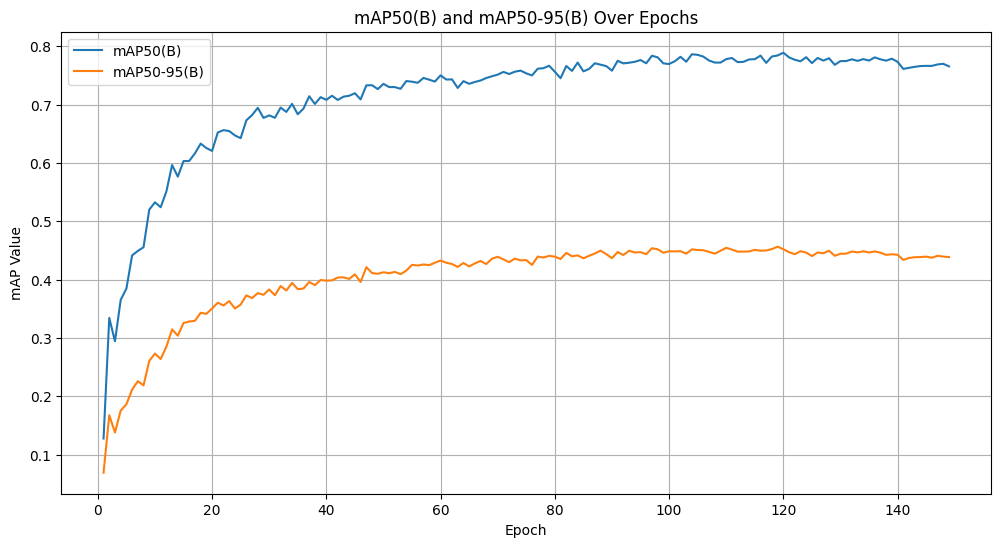

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os

results_path = '/content/runs/detect/train/results.csv'

if os.path.exists(results_path):
    results_df = pd.read_csv(results_path)

    results_df.columns = results_df.columns.str.strip()

    print("Hasil pelatihan (5 baris terakhir):")
    display(results_df.tail())

    plt.figure(figsize=(12, 6))
    plt.plot(results_df['epoch'], results_df['metrics/mAP50(B)'], label='mAP50(B)')
    plt.plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'], label='mAP50-95(B)')
    plt.title('mAP50(B) and mAP50-95(B) Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('mAP Value')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print(f"File hasil pelatihan tidak ditemukan di: {results_path}")
    print("Pastikan model telah selesai melatih dan menyimpan hasilnya.")

In [ ]:
model.predict(
    source="/content/insulator4.jpg",
    save=True,
    conf=0.25
)


image 1/1 /content/insulator4.jpg: 480x640 2 bracings, 2 insulators, 64.5ms
Speed: 4.9ms preprocess, 64.5ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'arching horn', 1: 'bracing', 2: 'insulator', 3: 'kabel'}
 obb: None
 orig_img: array([[[252, 247, 238],
         [252, 247, 238],
         [250, 248, 238],
         ...,
         [218, 213, 204],
         [218, 213, 204],
         [218, 213, 204]],
 
        [[251, 246, 237],
         [252, 247, 238],
         [251, 249, 239],
         ...,
         [218, 213, 204],
         [218, 213, 204],
         [218, 213, 204]],
 
        [[251, 246, 237],
         [252, 247, 238],
         [251, 249, 239],
         ...,
         [218, 213, 204],
         [218, 213, 204],
         [218, 213, 204]],
 
        ...,
 
        [[240, 240, 234],
         [230, 230, 224],
         [214, 216, 210],
         ...,
         [192, 187, 178],
         [192, 187, 178],
         [192, 187, 178]],
 
        [[240, 240, 234],
         [228, 228, 222],
         [


image 1/1 /content/insulator4.jpg: 480x640 1 aksesoris sisi hot, 1 insulator, 12.9ms
Speed: 3.0ms preprocess, 12.9ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


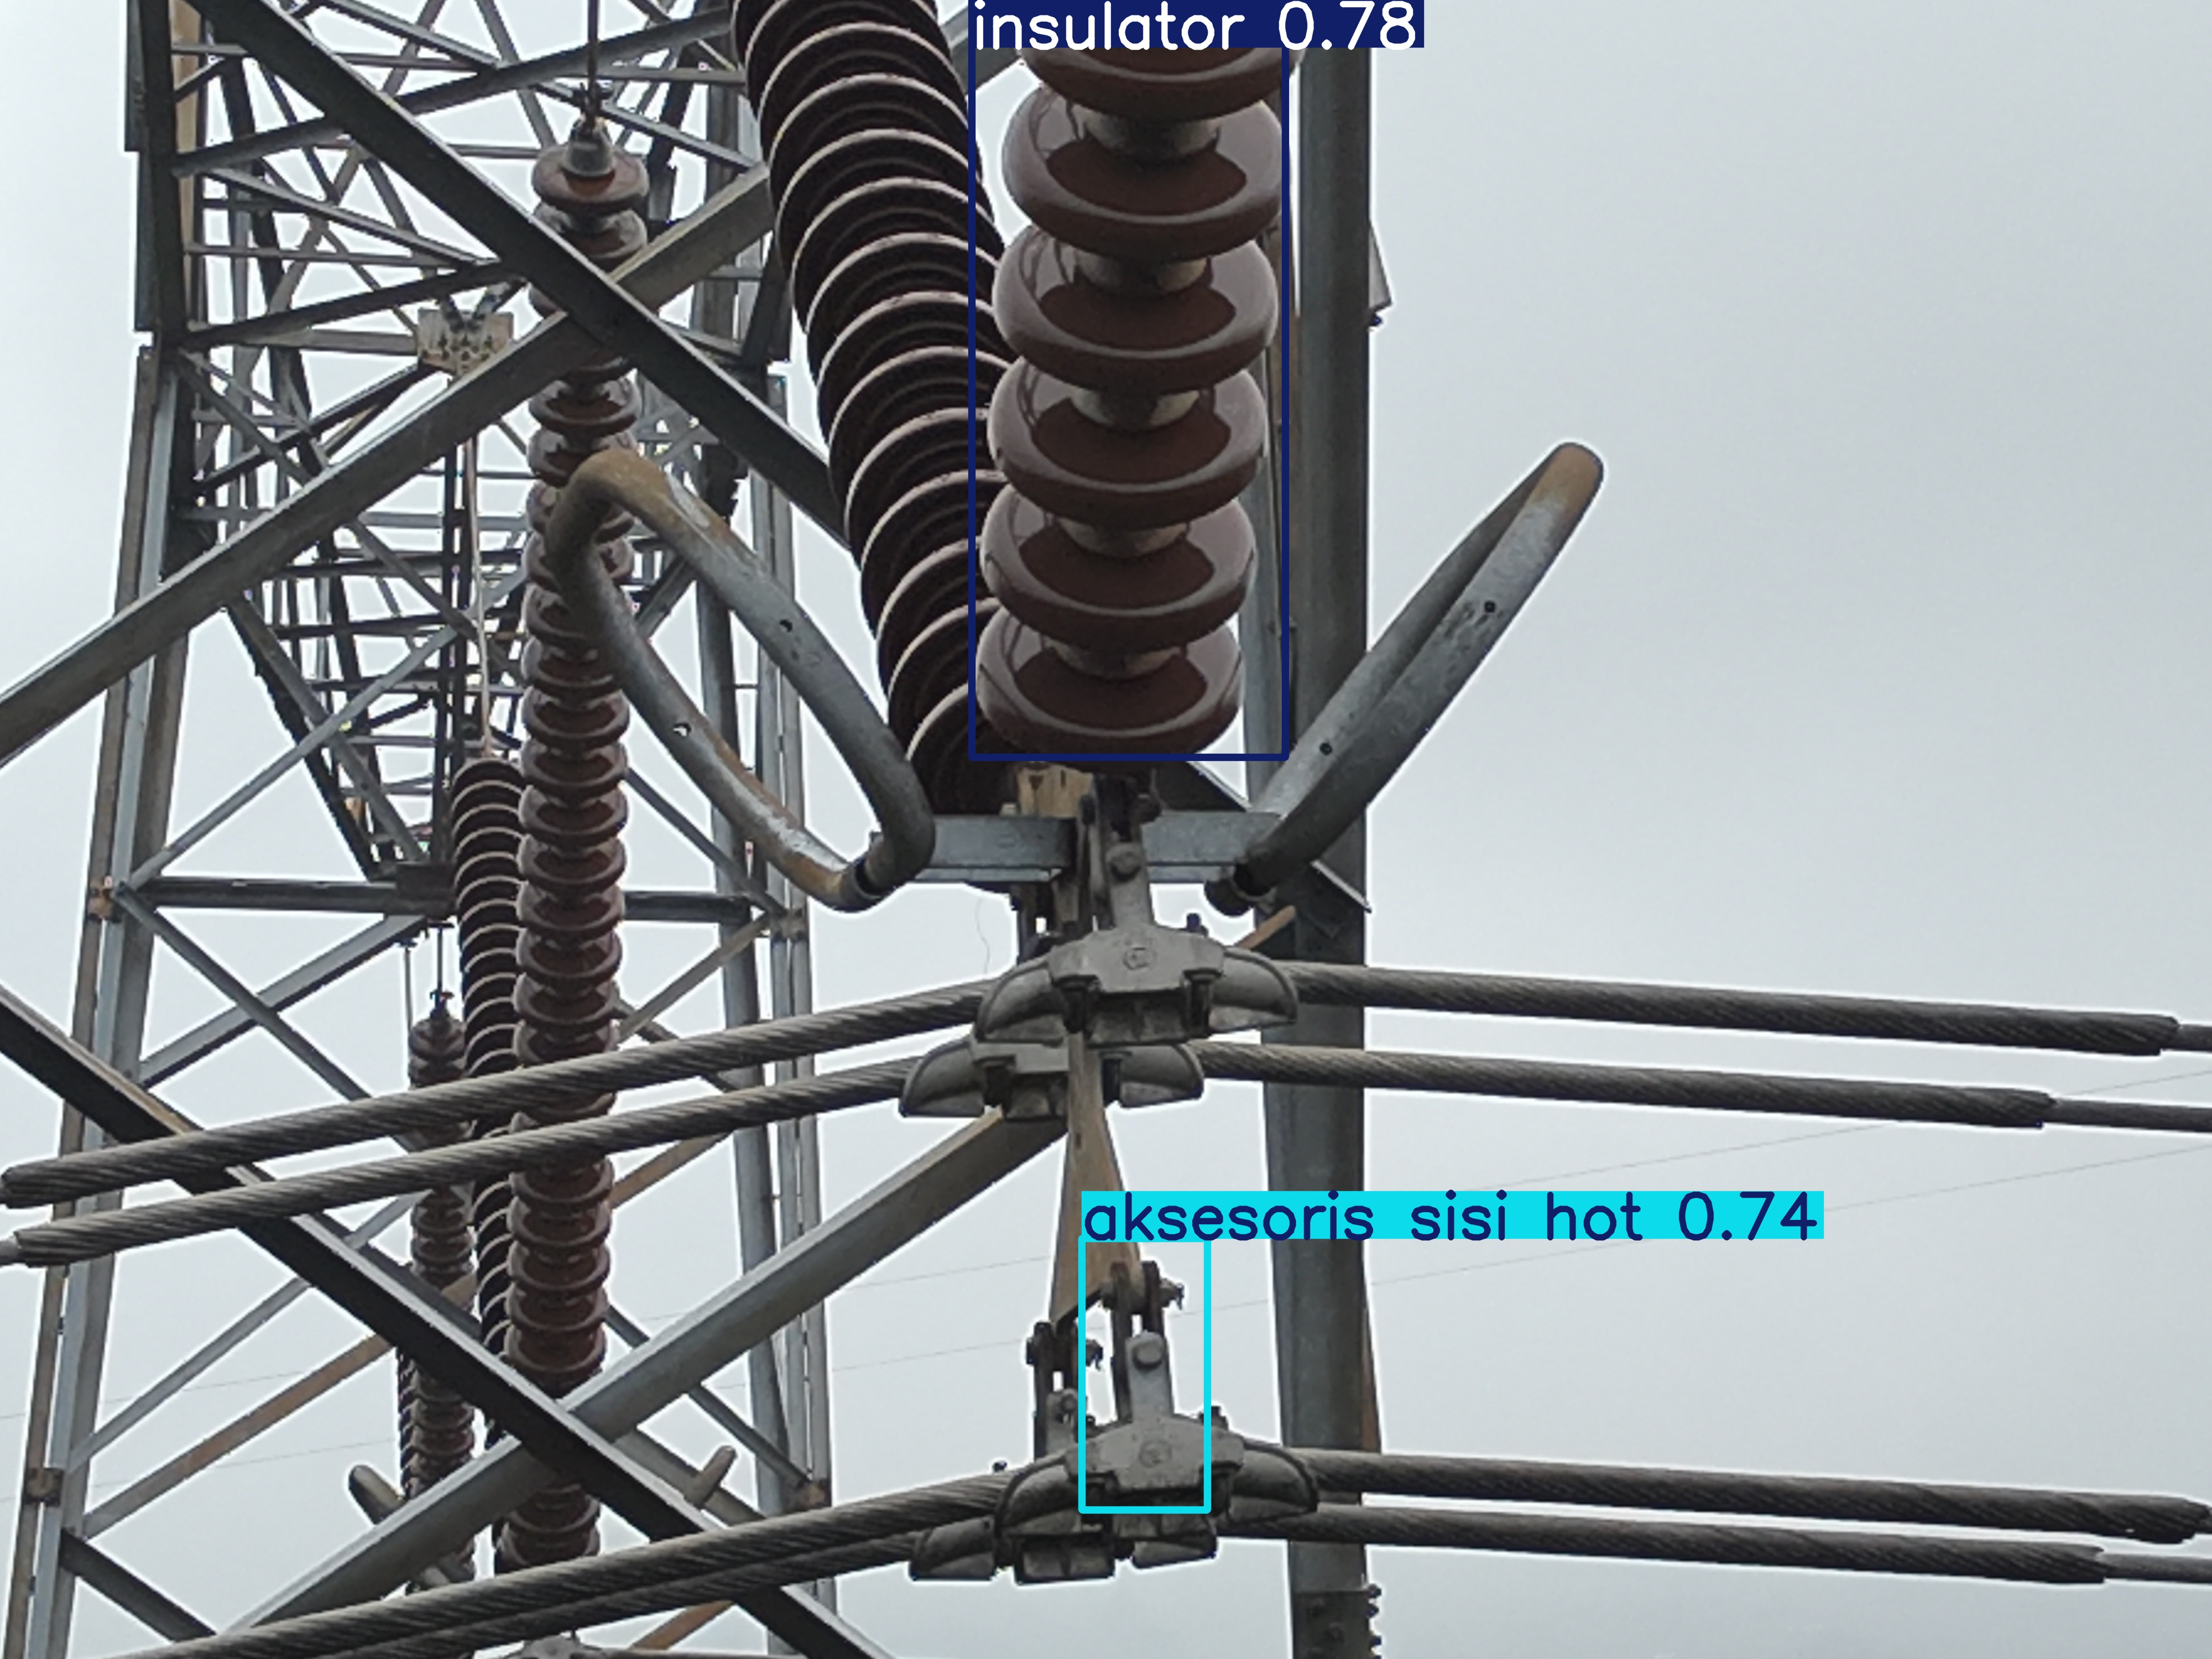

In [15]:
from IPython.display import Image
import os

results = model.predict(
    source="/content/insulator4.jpg",
    save=True,
    conf=0.6
)

save_dir = results[0].save_dir if results and hasattr(results[0], 'save_dir') else '/content/runs/detect/predict'

predicted_image_name = os.path.basename('/content/insulator4.jpg')
predicted_image_path = os.path.join(save_dir, predicted_image_name)

if os.path.exists(predicted_image_path):
    display(Image(filename=predicted_image_path))
else:
    print(f"Gambar hasil deteksi tidak ditemukan di: {predicted_image_path}")
    print("Pastikan model.predict berjalan dan menyimpan hasilnya dengan benar.")

In [13]:
import shutil
import os

source_path = '/content/runs/detect/train/weights/best.pt'

destination_path = '/content/best.pt'

if os.path.exists(source_path):
    shutil.copy(source_path, destination_path)
    print(f"Model \'{os.path.basename(source_path)}\' berhasil disalin ke \'{destination_path}\'")
    print("Anda sekarang bisa mengunduh file ini dari panel File di sebelah kiri Colab.")
else:
    print(f"File \'{source_path}\' tidak ditemukan. Pastikan pelatihan telah selesai dan menghasilkan file best.pt.")

Model 'best.pt' berhasil disalin ke '/content/best.pt'
Anda sekarang bisa mengunduh file ini dari panel File di sebelah kiri Colab.
